<a href="https://colab.research.google.com/github/sandhiyajeganathan2002-gif/INT8_Detection_Under_Degradation/blob/main/INT8_Detection_Under_Degradation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Installing Ultralytics and OpenVINO
!pip install -q ultralytics openvino

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.6/45.6 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 35.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 MB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.9/63.9 kB 3.1 MB/s eta 0:00:00


In [ ]:
# Loading Pretrained model YOLOv8n
from ultralytics import YOLO
model = YOLO("yolov8n.pt")

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.



image 1/1 /content/bus.jpg: 640x480 4 persons, 1 bus, 1 stop sign, 463.2ms
Speed: 25.3ms preprocess, 463.2ms inference, 48.7ms postprocess per image at shape (1, 3, 640, 480)


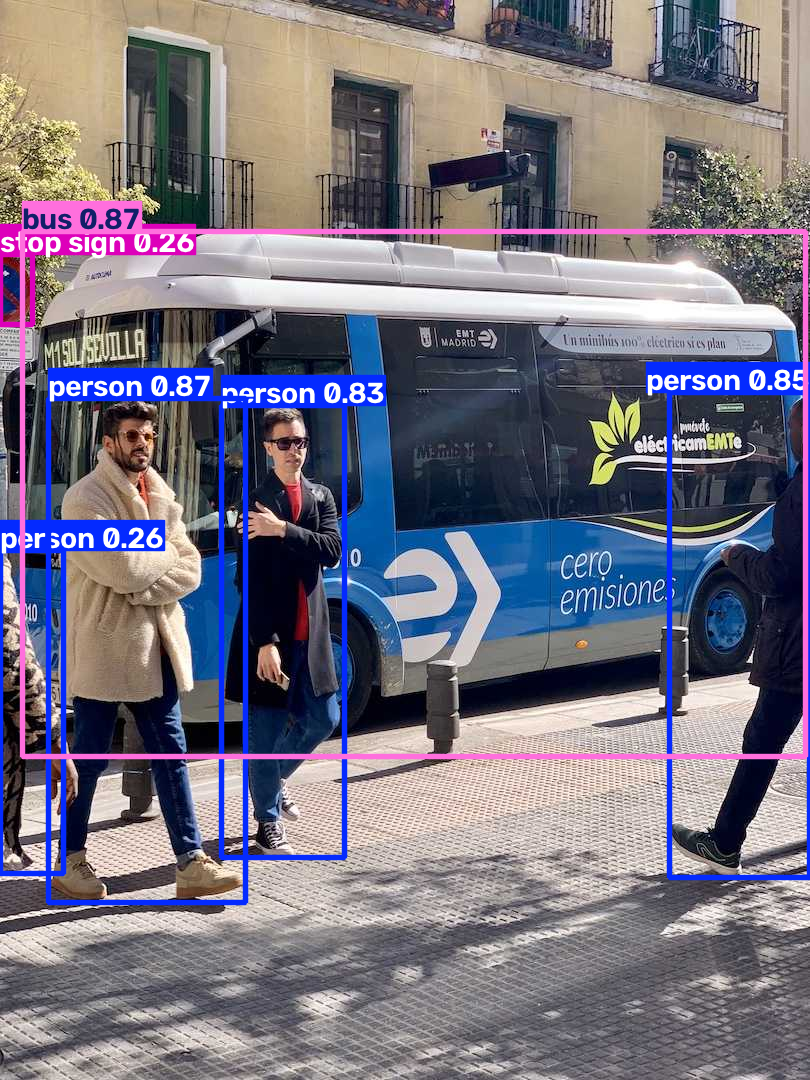

In [ ]:
# Testing whether YOLO works
results = model("https://ultralytics.com/images/bus.jpg")
results[0].show()

In [ ]:
# Downloading coco validation images
!wget -q http://images.cocodataset.org/zips/val2017.zip

In [ ]:
# Extracting
!unzip -q val2017.zip

In [ ]:
# Downloading COCO Ground-Truth Annotations # correct ans for each image called ground truth
!wget -q http://images.cocodataset.org/annotations/annotations_trainval2017.zip

In [ ]:
# Extracting
!unzip -q annotations_trainval2017.zip

In [ ]:
!pip install -q pycocotools

In [ ]:
# COCO Dataset Initialization and Target Class Selection
from pycocotools.coco import COCO
coco = COCO("annotations/instances_val2017.json")

classes = ["person", "car", "bicycle", "traffic light", "stop sign"]
cat_ids = coco.getCatIds(catNms=classes)

print("Category IDs:", cat_ids)

loading annotations into memory...
Done (t=1.00s)
creating index...
index created!
Category IDs: [1, 2, 3, 10, 13]


In [ ]:
# Finding images containing target class images
img_ids = set()

for cat_id in cat_ids:
    ids = coco.getImgIds(catIds=[cat_id])
    img_ids.update(ids)

img_ids = list(img_ids)

print("Available images:", len(img_ids))

Available images: 2956


In [ ]:
# Randomly selecting 500 images # to get the same 500 images
import random
random.seed(42)
selected_img_ids = random.sample(img_ids, 500)

print("Selected images:", len(selected_img_ids))

Selected images: 500


In [ ]:
# Filtering Ground-Truth Annotations for the 500 Evaluation Images
import json

with open("annotations/instances_val2017.json", "r") as f:
    data = json.load(f)

selected = set(selected_img_ids)
annotations = [
    a for a in data["annotations"]
    if a["image_id"] in selected
    and a["category_id"] in cat_ids
]

print("Images:", len(selected))
print("Annotations:", len(annotations))

Images: 500
Annotations: 2544


In [ ]:
# Creating Clean Directory for Evaluation Images
import os
import shutil

if os.path.exists("data/images"):
    shutil.rmtree("data/images")

os.makedirs("data/images")

In [ ]:
# Verifying Evaluation Image Folder
print("Images in folder:", len(os.listdir("data/images")))

Images in folder: 0


In [ ]:
# Copying the selected 500 COCO Images
for image_id in selected_img_ids:
    image = next(x for x in data["images"] if x["id"] == image_id)

    src = "val2017/" + image["file_name"]
    dst = "data/images/" + image["file_name"]

    shutil.copy(src, dst)

print("Images copied:", len(os.listdir("data/images")))

Images copied: 500


In [ ]:
# FP32 inference on the selected 500 COCO  (running YOLOv8n)

results = model.predict(
    source="data/images",
    save=True,
    conf=0.001,
    iou=0.7
)


image 1/500 /content/data/images/000000000724.jpg: 640x480 8 persons, 96 cars, 3 buss, 6 trucks, 6 traffic lights, 8 stop signs, 7 benchs, 1 umbrella, 8 potted plants, 491.8ms
image 2/500 /content/data/images/000000000872.jpg: 640x640 21 persons, 4 frisbees, 13 sports balls, 2 baseball bats, 8 baseball gloves, 1 skateboard, 1 bottle, 1 cell phone, 495.9ms
image 3/500 /content/data/images/000000001353.jpg: 640x480 69 persons, 2 bicycles, 1 boat, 1 traffic light, 6 benchs, 17 handbags, 3 suitcases, 2 bottles, 2 knifes, 1 spoon, 31 chairs, 1 potted plant, 1 bed, 2 dining tables, 1 tv, 1 laptop, 2 remotes, 3 cell phones, 5 refrigerators, 4 books, 1 vase, 1 scissors, 357.5ms
image 4/500 /content/data/images/000000004134.jpg: 448x640 113 persons, 1 backpack, 6 handbags, 19 ties, 3 bottles, 22 wine glasss, 15 cups, 1 fork, 4 bowls, 1 pizza, 3 cakes, 74 chairs, 31 dining tables, 3 laptops, 1 remote, 1 cell phone, 2 books, 360.8ms
image 5/500 /content/data/images/000000005529.jpg: 640x448 5 pe

In [ ]:
# Converting FP32 Predictions to COCO Format
import json
import os

# Create filename → COCO image ID mapping
image_id_map = {
    image["file_name"]: image["id"]
    for image in data["images"]
}

# YOLO class → COCO category ID
cat_id = {
    0: 1,    # person
    1: 2,    # bicycle
    2: 3,    # car
    9: 10,   # traffic light
    11: 13   # stop sign
}

predictions = []

# Get the same image order used by YOLO
image_files = sorted(os.listdir("data/images"))

for result, filename in zip(results, image_files):

    # Get the correct COCO image ID
    image_id = image_id_map[filename]

    for box in result.boxes:

        cls = int(box.cls[0])

        if cls not in cat_id:
            continue

        x1, y1, x2, y2 = box.xyxy[0].tolist()

        predictions.append({
            "image_id": int(image_id),
            "category_id": cat_id[cls],
            "bbox": [x1, y1, x2 - x1, y2 - y1],
            "score": float(box.conf[0])
        })

with open("fp32_predictions.json", "w") as f:
    json.dump(predictions, f)

print("Predictions saved:", len(predictions))

Predictions saved: 34814


In [ ]:
# Creating COCO Ground Truth for the 500 Images
import json

with open("annotations/instances_val2017.json", "r") as f:
    coco_data = json.load(f)

# IMPORTANT: use the selected 500 images
selected_ids = set(selected_img_ids)

small_coco = {
    "info": coco_data["info"],
    "licenses": coco_data["licenses"],
    "images": [
        x for x in coco_data["images"]
        if x["id"] in selected_ids
    ],
    "annotations": [
        x for x in coco_data["annotations"]
        if x["image_id"] in selected_ids
        and x["category_id"] in [1, 2, 3, 10, 13]
    ],
    "categories": [
        x for x in coco_data["categories"]
        if x["name"] in classes
    ]
}

with open("annotations/instances_500.json", "w") as f:
    json.dump(small_coco, f)

print("Created images:", len(small_coco["images"]))
print("Created annotations:", len(small_coco["annotations"]))

Created images: 500
Created annotations: 2544


In [ ]:
# Get image IDs from predictions
prediction_ids = set(p["image_id"] for p in predictions)

# Get image IDs from our 500-image ground truth
ground_truth_ids = set(selected_img_ids)

print("Ground-truth images:", len(ground_truth_ids))
print("Prediction images:", len(prediction_ids))

print("Missing predictions:",
      len(ground_truth_ids - prediction_ids))

print("Extra prediction images:",
      len(prediction_ids - ground_truth_ids))

Ground-truth images: 500
Prediction images: 499
Missing predictions: 1
Extra prediction images: 0


In [ ]:
print("Missing image IDs:", sorted(ground_truth_ids - prediction_ids))

Missing image IDs: [180878]


In [ ]:
missing_ids = ground_truth_ids - prediction_ids

for image_id in sorted(missing_ids):
    anns = [
        a for a in small_coco["annotations"]
        if a["image_id"] == image_id
    ]

    print("Image:", image_id, "Ground-truth objects:", len(anns))

Image: 180878 Ground-truth objects: 1


In [ ]:
# Evaluating FP32 Baseline Using COCO Metrics
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval

coco_gt = COCO("annotations/instances_500.json")
coco_dt = coco_gt.loadRes("fp32_predictions.json")

evaluator = COCOeval(coco_gt, coco_dt, "bbox")

evaluator.evaluate()
evaluator.accumulate()
evaluator.summarize()

loading annotations into memory...
Done (t=0.08s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.36s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=7.93s).
Accumulating evaluation results...
DONE (t=0.72s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.425
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.620
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.451
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.201
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.581
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.704
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.253
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.486
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets

In [ ]:
#Verifying COCO Category ID and Class Mapping
print(coco_gt.getCatIds())
print(coco_gt.loadCats(coco_gt.getCatIds()))

[1, 2, 3, 10, 13]
[{'supercategory': 'person', 'id': 1, 'name': 'person'}, {'supercategory': 'vehicle', 'id': 2, 'name': 'bicycle'}, {'supercategory': 'vehicle', 'id': 3, 'name': 'car'}, {'supercategory': 'outdoor', 'id': 10, 'name': 'traffic light'}, {'supercategory': 'outdoor', 'id': 13, 'name': 'stop sign'}]


In [ ]:
# Calculating Per-Class AP @ IoU=0.50 (FP32)
class_names = ["person", "bicycle", "car", "traffic light", "stop sign"]

iou_index = 0   # index 0 in evaluator.params.iouThrs corresponds to IoU=0.50

fp32_ap = {}

for i, class_name in enumerate(class_names):
    ap = evaluator.eval["precision"][iou_index, :, i, 0, -1]
    ap = ap[ap > -1]

    if len(ap) > 0:
        fp32_ap[class_name] = round(ap.mean(), 3)
        print(class_name, "AP:", fp32_ap[class_name])


person AP: 0.766
bicycle AP: 0.569
car AP: 0.619
traffic light AP: 0.432
stop sign AP: 0.714


In [ ]:
# Saving the main baseline numbers
fp32_map50 = evaluator.stats[1]
fp32_map5095 = evaluator.stats[0]
fp32_ap_small = evaluator.stats[3]
fp32_ap_medium = evaluator.stats[4]
fp32_ap_large = evaluator.stats[5]

print("FP32 mAP@0.5       :", fp32_map50)
print("FP32 mAP@0.5:0.95  :", fp32_map5095)
print("FP32 AP Small      :", fp32_ap_small)
print("FP32 AP Medium     :", fp32_ap_medium)
print("FP32 AP Large      :", fp32_ap_large)

FP32 mAP@0.5       : 0.6198640064310819
FP32 mAP@0.5:0.95  : 0.4251281538087495
FP32 AP Small      : 0.20064372409478584
FP32 AP Medium     : 0.5809113387881316
FP32 AP Large      : 0.7040151098799925


In [ ]:
import os

os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

In [ ]:
import os
model_path = "yolov8n.pt"
size_mb = os.path.getsize(model_path) / (1024 * 1024)

print("FP32 model size:", round(size_mb, 2), "MB")

FP32 model size: 6.25 MB


In [ ]:
!git clone https://github.com/sandhiyajeganathan2002-gif/INT8_Detection_Under_Degradation_Trial_Task.git
%cd INT8_Detection_Under_Degradation_Trial_Task


Cloning into 'INT8_Detection_Under_Degradation_Trial_Task'...
remote: Enumerating objects: 30, done.
remote: Counting objects: 100% (30/30), done.
remote: Compressing objects: 100% (26/26), done.
remote: Total 30 (delta 5), reused 14 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (30/30), 14.84 MiB | 8.16 MiB/s, done.
Resolving deltas: 100% (5/5), done.
/content/INT8_Detection_Under_Degradation_Trial_Task


In [ ]:
import os

print(os.getcwd())
print(os.listdir())

/content/INT8_Detection_Under_Degradation_Trial_Task
['README.md', '.git', '.gitignore', 'INT8_Detection_Under_Degradation.ipynb']


In [ ]:
import os

print(os.listdir("/content"))

['.config', 'fp32_predictions.json', 'yolov8n.pt', 'INT8_Detection_Under_Degradation_Trial_Task', 'bus.jpg', 'runs', 'val2017.zip', 'data', 'annotations_trainval2017.zip', 'val2017', 'annotations', 'sample_data']


In [ ]:
import shutil
import os

repo = "/content/INT8_Detection_Under_Degradation_Trial_Task"

# Copy our 500 evaluation images
shutil.copytree(
    "/content/data",
    repo + "/data",
    dirs_exist_ok=True
)

# Copy our 500-image COCO ground truth
os.makedirs(repo + "/annotations", exist_ok=True)

shutil.copy(
    "/content/annotations/instances_500.json",
    repo + "/annotations/instances_500.json"
)

# Copy FP32 predictions
shutil.copy(
    "/content/fp32_predictions.json",
    repo + "/fp32_predictions.json"
)

print("Experiment files copied into repository.")

Experiment files copied into repository.


In [ ]:
%%writefile .gitignore

# COCO data
data/
val2017/
*.zip

# Generated annotations
annotations/

# Model files
*.pt
*.onnx
*.xml
*.bin

# Generated predictions
*_predictions.json

# Experiment outputs
runs/

# Python cache
__pycache__/
*.pyc

# Jupyter
.ipynb_checkpoints/

Overwriting .gitignore


In [ ]:
!git config --global user.name "Sandhiya J"
!git config --global user.email "sandhiyajeganathan2002@gmail.com"

In [ ]:
!git add .gitignore
!git commit -m "Set up FP32 baseline and CPU benchmarking"

On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean


In [ ]:
!git push origin main

fatal: could not read Username for 'https://github.com': No such device or address


In [ ]:
from getpass import getpass

token = getpass("Paste your GitHub token: ")

Paste your GitHub token: ··········


In [ ]:
import subprocess

result = subprocess.run(
    ["gh", "auth", "login", "--with-token"],
    input=token + "\n",
    text=True,
    capture_output=True
)

print(result.stderr if result.returncode != 0 else "GitHub authentication successful")

GitHub authentication successful


In [ ]:
!git push origin main

fatal: could not read Username for 'https://github.com': No such device or address


In [ ]:
!gh auth setup-git

In [ ]:
!git push origin main

Everything up-to-date


In [ ]:
!git remote set-url origin https://github.com/sandhiyajeganathan2002-gif/INT8_Detection_Under_Degradation.git

In [ ]:
!git remote -v

origin	https://github.com/sandhiyajeganathan2002-gif/INT8_Detection_Under_Degradation.git (fetch)
origin	https://github.com/sandhiyajeganathan2002-gif/INT8_Detection_Under_Degradation.git (push)


In [ ]:
!git status

On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean


In [ ]:
# Part 1 — Quantize

In [ ]:
# "Exporting FP32 YOLOv8n to OpenVINO format"
model.export(format="openvino")

Ultralytics 8.4.121 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from 'yolov8n.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 84, 8400) (0.0 MB)

OpenVINO: starting export with openvino 2026.3.0-22451-8a17657b995-releases/2026/3...
OpenVINO: export success ✅ 6.5s, saved as 'yolov8n_openvino_model/' (12.3 MB)

Export complete (7.4s)
Results saved to /content/INT8_Detection_Under_Degradation_Trial_Task/yolov8n_openvino_model
Predict:         yolo predict task=detect model=yolov8n_openvino_model/ imgsz=640 
Validate:        yolo val task=detect model=yolov8n_openvino_model/ imgsz=640 data=coco.yaml  
Visualize:       https://netron.app


'yolov8n_openvino_model/'

In [ ]:
# Loading Calibration Image List
import os
calibration_images = os.listdir("data/images")

print("Calibration images:", len(calibration_images))

Calibration images: 500


In [ ]:
#  "Installing NNCF (quantization library)"
!pip install -q nncf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 795.0/795.0 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 8.1 MB/s eta 0:00:00


In [ ]:
# "Loading FP32 OpenVINO model for quantization"
import nncf
from openvino import Core

core = Core()

fp32_ov_model= core.read_model(
    "yolov8n_openvino_model/yolov8n.xml"
)

print("Model loaded")

Model loaded


In [ ]:
# Preprocessing images for calibration dataset
import cv2
import numpy as np
import os

def letterbox(image, new_shape=(640, 640), color=(114, 114, 114)):
    shape = image.shape[:2]
    r = min(new_shape[0] / shape[0], new_shape[1] / shape[1])
    new_unpad = (int(round(shape[1] * r)), int(round(shape[0] * r)))

    image = cv2.resize(image, new_unpad)

    dw = new_shape[1] - new_unpad[0]
    dh = new_shape[0] - new_unpad[1]

    top = dh // 2
    bottom = dh - top
    left = dw // 2
    right = dw - left

    image = cv2.copyMakeBorder(image, top, bottom, left, right, cv2.BORDER_CONSTANT, value=color)
    return image


image_dir = "data/images"
calibration_data = []

for filename in calibration_images:
    image = cv2.imread(os.path.join(image_dir, filename))

    image = letterbox(image=image)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = image.astype(np.float32) / 255.0
    image = np.transpose(image, (2, 0, 1))
    image = np.expand_dims(image, axis=0)

    calibration_data.append(image)

print("Calibration samples:", len(calibration_data))
print("Shape:", calibration_data[0].shape)

Calibration samples: 500
Shape: (1, 3, 640, 640)


In [ ]:
# Generating the INT8 Quantized Model
import nncf
import numpy as np

# Converting calibration list into NNCF dataset
calibration_dataset = nncf.Dataset(calibration_data)

# Performing INT8 quantization
int8_model = nncf.quantize(
    fp32_ov_model,
    calibration_dataset
)

print("INT8 quantization completed!")

Output()

Output()

INT8 quantization completed!


In [ ]:
# saving the INT8 model
from openvino import save_model

save_model(
    int8_model,
    "yolov8n_int8.xml"
)

print("INT8 model saved!")

INT8 model saved!


In [ ]:
# Verifying saved INT8 Model Files
import os

print(os.path.exists("yolov8n_int8.xml"))
print(os.path.exists("yolov8n_int8.bin"))

True
True


In [ ]:
# Compiling INT8 Model for CPU Inference
import cv2
import numpy as np
from openvino import Core

core = Core()

int8_ov_model  = core.read_model("yolov8n_int8.xml")
compiled_model = core.compile_model(int8_ov_model, "CPU")

input_layer = compiled_model.input(0)
output_layer = compiled_model.output(0)

int8_predictions = []

print("INT8 model ready!")

INT8 model ready!


In [ ]:
# Running a Single INT8 Inference and Inspecting Output
image_path = "data/images/" + os.listdir("data/images")[0]

image = cv2.imread(image_path)

image = letterbox(image=image)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
image = image.astype(np.float32) / 255.0
image = np.transpose(image, (2, 0, 1))
image = np.expand_dims(image, axis=0)

output = compiled_model([image])[output_layer]

print("Input shape:", image.shape)
print("Output shape:", output.shape)

Input shape: (1, 3, 640, 640)
Output shape: (1, 84, 8400)


In [ ]:
# Extracting and Inspecting Raw Model Output
output = output[0]

print("Raw output shape:", output.shape)

Raw output shape: (84, 8400)


In [ ]:
# Running INT8 Inference on All Evaluation Images

int8_predictions = []

for filename in image_files:

    image = cv2.imread("data/images/" + filename)

    # Letterbox
    processed = letterbox(image=image)

    # Convert to RGB and normalize
    processed = cv2.cvtColor(processed, cv2.COLOR_BGR2RGB)
    processed = processed.astype(np.float32) / 255.0

    # Change to model format
    processed = np.transpose(processed, (2, 0, 1))
    processed = np.expand_dims(processed, axis=0)

    # INT8 inference
    output = compiled_model([processed])[output_layer]

    int8_predictions.append(output)

print("INT8 images processed:", len(int8_predictions))

INT8 images processed: 500


In [ ]:
# Decoding INT8 Predictions using Non-Maximum Suppression (NMS)
from ultralytics.utils.nms import non_max_suppression
import torch

decoded_predictions = []

for raw_output in int8_predictions:
    raw = torch.tensor(raw_output)
    detections = non_max_suppression(raw, conf_thres=0.001, iou_thres=0.7)
    decoded_predictions.append(detections[0])

print("Images decoded:", len(decoded_predictions))

Images decoded: 500


In [ ]:
# Scaling INT8 Detection Boxes to Original Image Coordinates
from ultralytics.utils.ops import scale_boxes

final_int8_predictions = []

for i, detections in enumerate(decoded_predictions):

    filename = image_files[i]

    image = cv2.imread("data/images/" + filename)
    original_shape = image.shape[:2]

    if len(detections) > 0:
        detections = detections.clone()

        # Convert boxes from 640x640 back to original image size
        detections[:, :4] = scale_boxes(
            (640, 640),
            detections[:, :4],
            original_shape
        )

    final_int8_predictions.append(detections)

print("Boxes mapped to original image size:", len(final_int8_predictions))

Boxes mapped to original image size: 500


In [ ]:
# Converting INT8 Predictions to COCO Evaluation Format
import json

# YOLO class ID → COCO category ID
cat_id = {
    0: 1,    # person
    1: 2,    # bicycle
    2: 3,    # car
    9: 10,   # traffic light
    11: 13   # stop sign
}

int8_coco_predictions = []

for detections, filename in zip(final_int8_predictions, image_files):

    # Get image ID from filename
    image_id = next(
        x["id"]
        for x in coco_data["images"]
        if x["file_name"] == filename
    )

    for detection in detections:

        x1, y1, x2, y2, score, cls = detection.tolist()

        cls = int(cls)

        # Keep only our 5 target classes
        if cls not in cat_id:
            continue

        width = x2 - x1
        height = y2 - y1

        int8_coco_predictions.append({
            "image_id": int(image_id),
            "category_id": cat_id[cls],
            "bbox": [x1, y1, width, height],
            "score": float(score)
        })

print("INT8 predictions:", len(int8_coco_predictions))

INT8 predictions: 31654


In [ ]:
# Saving INT8 Predictions as COCO JSON
with open("int8_predictions.json", "w") as f:
    json.dump(int8_coco_predictions, f)

print("Saved: int8_predictions.json")

Saved: int8_predictions.json


In [ ]:
# Evaluating INT8 Predictions Using COCO Evaluation
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval

# Load your 500-image ground-truth annotations
coco_gt = COCO("annotations/instances_500.json")

# Load INT8 predictions
coco_dt = coco_gt.loadRes("int8_predictions.json")

# COCO evaluation
evaluator = COCOeval(coco_gt, coco_dt, "bbox")

# Evaluate exactly these 500 images
evaluator.params.imgIds = list(selected_ids)

evaluator.evaluate()
evaluator.accumulate()
evaluator.summarize()

loading annotations into memory...
Done (t=0.09s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.36s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=7.14s).
Accumulating evaluation results...
DONE (t=0.68s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.332
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.545
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.368
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.126
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.470
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.649
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.217
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.418
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets

In [ ]:
# Comparing FP32 vs INT8 mAP and Accuracy Drop
int8_map50 = evaluator.stats[1]
int8_map5095 = evaluator.stats[0]

print("FP32 mAP@0.5     :", fp32_map50)
print("INT8 mAP@0.5     :", int8_map50)
print("Drop            :", fp32_map50 - int8_map50)

print()

print("FP32 mAP@0.5:0.95:", fp32_map5095)
print("INT8 mAP@0.5:0.95:", int8_map5095)
print("Drop            :", fp32_map5095 - int8_map5095)

FP32 mAP@0.5     : 0.6198640064310819
INT8 mAP@0.5     : 0.5448632065567314
Drop            : 0.07500079987435049

FP32 mAP@0.5:0.95: 0.4251281538087495
INT8 mAP@0.5:0.95: 0.33196808675899925
Drop            : 0.09316006704975027


In [ ]:
# Per-Class AP Delta: FP32 vs INT8 (both at IoU=0.50)
iou_index = 0

int8_ap = {}

for i, class_name in enumerate(class_names):
    ap = evaluator.eval["precision"][iou_index, :, i, 0, -1]
    ap = ap[ap > -1]

    if len(ap) > 0:
        int8_ap[class_name] = round(ap.mean(), 3)

for cls in class_names:
    delta = int8_ap[cls] - fp32_ap[cls]
    print(cls, "FP32:", fp32_ap[cls], "INT8:", int8_ap[cls], "Delta:", round(delta, 3))

person FP32: 0.766 INT8: 0.706 Delta: -0.06
bicycle FP32: 0.569 INT8: 0.456 Delta: -0.113
car FP32: 0.619 INT8: 0.554 Delta: -0.065
traffic light FP32: 0.432 INT8: 0.336 Delta: -0.096
stop sign FP32: 0.714 INT8: 0.672 Delta: -0.042


In [ ]:
# Extracting INT8 AP by Object Size
print("INT8 Small AP :", evaluator.stats[3])
print("INT8 Medium AP:", evaluator.stats[4])
print("INT8 Large AP :", evaluator.stats[5])

INT8 Small AP : 0.12628931224728654
INT8 Medium AP: 0.46990291169636017
INT8 Large AP : 0.6488841018234861


In [ ]:
# Comparing FP32 vs INT8 Model Size
import os

fp32_size = (
    os.path.getsize("yolov8n_openvino_model/yolov8n.xml") +
    os.path.getsize("yolov8n_openvino_model/yolov8n.bin")
)

int8_size = (
    os.path.getsize("yolov8n_int8.xml") +
    os.path.getsize("yolov8n_int8.bin")
)

print(f"FP32 model size: {fp32_size / (1024**2):.2f} MB")
print(f"INT8 model size: {int8_size / (1024**2):.2f} MB")
print(f"Size reduction: {(1 - int8_size/fp32_size)*100:.2f}%")

FP32 model size: 12.34 MB
INT8 model size: 3.59 MB
Size reduction: 70.93%


In [ ]:
# Measuring Single-Threaded FP32 CPU Inference Latency
import time
import numpy as np

core = Core()

fp32_model = core.read_model(
    "yolov8n_openvino_model/yolov8n.xml"
)

fp32_compiled = core.compile_model(
    fp32_model,
    "CPU",
    config={"INFERENCE_NUM_THREADS": "1"}
)

fp32_input = fp32_compiled.input(0)

# Use one prepared image
test_input = processed.astype(np.float32)

# Warm-up
for _ in range(10):
    fp32_compiled([test_input])

# Benchmark
latencies_fp32 = []

for _ in range(100):
    start = time.perf_counter()

    fp32_compiled([test_input])

    end = time.perf_counter()

    latencies_fp32.append((end - start) * 1000)

print(f"FP32 Mean latency: {np.mean(latencies_fp32):.2f} ms")
print(f"FP32 P95 latency : {np.percentile(latencies_fp32, 95):.2f} ms")

FP32 Mean latency: 397.90 ms
FP32 P95 latency : 449.43 ms


In [ ]:
# Measuring Single-Threaded INT8 CPU Inference Latency
import time
import numpy as np

# Compile INT8 model with 1 CPU thread
int8_compiled = core.compile_model(
    int8_ov_model,
    "CPU",
    config={"INFERENCE_NUM_THREADS": "1"}
)

int8_input = int8_compiled.input(0)

# Warm-up
for _ in range(10):
    int8_compiled([test_input])

# Benchmark
latencies_int8 = []

for _ in range(100):
    start = time.perf_counter()

    int8_compiled([test_input])

    end = time.perf_counter()

    latencies_int8.append((end - start) * 1000)

print(f"INT8 Mean latency: {np.mean(latencies_int8):.2f} ms")
print(f"INT8 P95 latency : {np.percentile(latencies_int8, 95):.2f} ms")

INT8 Mean latency: 262.83 ms
INT8 P95 latency : 275.11 ms


In [ ]:
# Comparing FP32 vs INT8 CPU Latency & Calculating Speedup
print("FP32 Mean latency :", np.mean(latencies_fp32))
print("INT8 Mean latency :", np.mean(latencies_int8))

print("FP32 P95 latency  :", np.percentile(latencies_fp32, 95))
print("INT8 P95 latency  :", np.percentile(latencies_int8, 95))

mean_speedup = np.mean(latencies_fp32) / np.mean(latencies_int8)

print(f"Mean latency speedup: {mean_speedup:.2f}x")

FP32 Mean latency : 397.89828054999816
INT8 Mean latency : 262.82773086999214
FP32 P95 latency  : 449.42911190007635
INT8 P95 latency  : 275.11399725000274
Mean latency speedup: 1.51x


In [ ]:
# Identifying CPU Model Used for Benchmarking
!lscpu | grep "Model name"

Model name:                              Intel(R) Xeon(R) CPU @ 2.20GHz


In [ ]:
## PART-2  Degrade

In [ ]:
# Importing libraries
import cv2
import os
import numpy as np
from pathlib import Path

In [ ]:
# Defining original image folder
SOURCE_DIR = "/content/data/images"

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png"}

image_paths = [
    os.path.join(SOURCE_DIR, f)
    for f in os.listdir(SOURCE_DIR)
    if Path(f).suffix.lower() in IMAGE_EXTENSIONS
]

image_paths = sorted(image_paths)

print("Number of images:", len(image_paths))
print("First image:", image_paths[0])

Number of images: 500
First image: /content/data/images/000000000724.jpg


In [ ]:
# Creating degradation folders
BASE_DEG_DIR = "/content/degraded"

degradation_names = [
    "motion_blur",
    "low_light",
    "jpeg_q30",
    "downscale_50"
]

for name in degradation_names:
    os.makedirs(
        os.path.join(BASE_DEG_DIR, name),
        exist_ok=True
    )

print("Degradation folders created.")

Degradation folders created.


In [ ]:
# Motion Blur
def apply_motion_blur(image, kernel_size=15):
    kernel = np.zeros((kernel_size, kernel_size))
    kernel[kernel_size // 2, :] = 1
    kernel = kernel / kernel_size

    blurred = cv2.filter2D(image, -1, kernel)

    return blurred

In [ ]:
# Low-light transformation
def apply_low_light(image, gamma=2.0):
    normalized = image / 255.0

    darkened = np.power(normalized, gamma)

    darkened = np.clip(darkened * 255, 0, 255)

    return darkened.astype(np.uint8)

In [ ]:
# JPEG quality 30
def apply_jpeg_compression(image, quality=30):
    encode_param = [
        int(cv2.IMWRITE_JPEG_QUALITY),
        quality
    ]

    success, encoded = cv2.imencode(
        ".jpg",
        image,
        encode_param
    )

    if not success:
        raise RuntimeError("JPEG encoding failed")

    compressed = cv2.imdecode(
        encoded,
        cv2.IMREAD_COLOR
    )

    return compressed

In [ ]:
# Downscale 50%, then upscale
def apply_downscale_upscale(image, scale=0.5):
    original_height, original_width = image.shape[:2]

    small_width = int(original_width * scale)
    small_height = int(original_height * scale)

    small = cv2.resize(
        image,
        (small_width, small_height),
        interpolation=cv2.INTER_AREA
    )

    restored = cv2.resize(
        small,
        (original_width, original_height),
        interpolation=cv2.INTER_LINEAR
    )

    return restored

In [ ]:
# Generate all four degraded datasets
for image_path in image_paths:

    filename = os.path.basename(image_path)

    image = cv2.imread(image_path)

    if image is None:
        print("Could not read:", image_path)
        continue

    # 1. Motion blur
    motion = apply_motion_blur(image, kernel_size=15)

    cv2.imwrite(
        os.path.join(BASE_DEG_DIR, "motion_blur", filename),
        motion
    )

    # 2. Low light
    low_light = apply_low_light(image, gamma=2.0)

    cv2.imwrite(
        os.path.join(BASE_DEG_DIR, "low_light", filename),
        low_light
    )

    # 3. JPEG quality 30
    jpeg = apply_jpeg_compression(image, quality=30)

    cv2.imwrite(
        os.path.join(BASE_DEG_DIR, "jpeg_q30", filename),
        jpeg
    )

    # 4. Downscale 50% → upscale
    resized = apply_downscale_upscale(image, scale=0.5)

    cv2.imwrite(
        os.path.join(BASE_DEG_DIR, "downscale_50", filename),
        resized
    )

print("All degraded datasets created.")

All degraded datasets created.


In [ ]:
# Verifying the datasets
for name in degradation_names:

    folder = os.path.join(BASE_DEG_DIR, name)

    count = len([
        f for f in os.listdir(folder)
        if Path(f).suffix.lower() in IMAGE_EXTENSIONS
    ])

    print(name, ":", count)

motion_blur : 500
low_light : 500
jpeg_q30 : 500
downscale_50 : 500


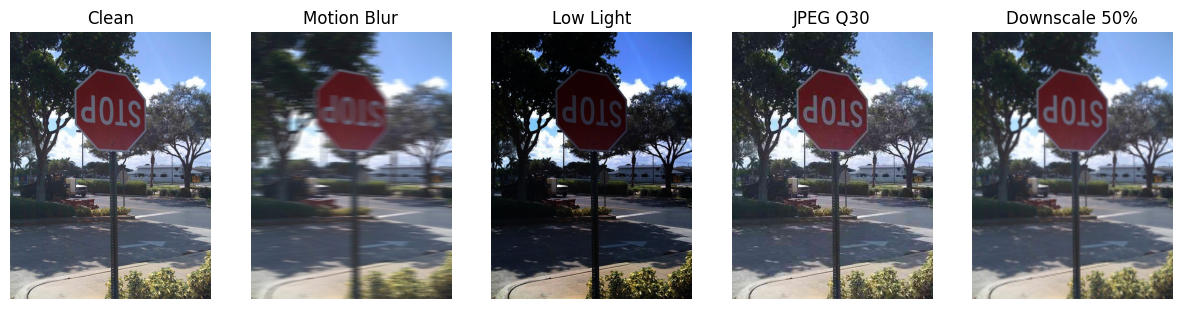

In [ ]:
# Visually inspecting one image
import matplotlib.pyplot as plt

sample_name = os.path.basename(image_paths[0])

clean = cv2.imread(image_paths[0])
motion = cv2.imread(
    os.path.join(BASE_DEG_DIR, "motion_blur", sample_name)
)
low = cv2.imread(
    os.path.join(BASE_DEG_DIR, "low_light", sample_name)
)
jpeg = cv2.imread(
    os.path.join(BASE_DEG_DIR, "jpeg_q30", sample_name)
)
down = cv2.imread(
    os.path.join(BASE_DEG_DIR, "downscale_50", sample_name)
)

plt.figure(figsize=(15, 8))

images = [clean, motion, low, jpeg, down]
titles = [
    "Clean",
    "Motion Blur",
    "Low Light",
    "JPEG Q30",
    "Downscale 50%"
]

for i in range(5):
    plt.subplot(1, 5, i + 1)

    plt.imshow(cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB))

    plt.title(titles[i])
    plt.axis("off")

plt.show()

In [ ]:
# Run FP32 on Motion Blur
model = YOLO("yolov8n.pt")

In [ ]:
motion_results_fp32 = model.predict(
    source=os.path.join(BASE_DEG_DIR, "motion_blur"),
    imgsz=640,
    conf=0.001,
    save=False,
    verbose=False
)

print("Motion blur FP32 inference complete.")

Motion blur FP32 inference complete.


In [ ]:
# Converting Motion-Blur FP32 Detections to COCO Format
import json

YOLO_TO_COCO = {
    0: 1,    # person
    1: 2,    # bicycle
    2: 3,    # car
    9: 10,   # traffic light
    11: 13   # stop sign
}

motion_blur_predictions = []

for result in motion_results_fp32:

    filename = os.path.basename(result.path)
    image_id = image_id_map[filename]

    for box in result.boxes:

        cls = int(box.cls[0])

        if cls not in YOLO_TO_COCO:
            continue

        x1, y1, x2, y2 = box.xyxy[0].tolist()
        score = float(box.conf[0])

        motion_blur_predictions.append({
            "image_id": int(image_id),
            "category_id": YOLO_TO_COCO[cls],
            "bbox": [x1, y1, x2 - x1, y2 - y1],
            "score": score
        })

print("Motion blur predictions created:", len(motion_blur_predictions))

Motion blur predictions created: 49134


In [ ]:
# Saving Motion-Blur Predictions as COCO JSON
with open("motion_blur_predictions.json", "w") as f:
    json.dump(motion_blur_predictions, f)

print("Saved: motion_blur_predictions.json")

Saved: motion_blur_predictions.json


In [ ]:
# Evaluating Motion-Blur FP32 Predictions Using COCO Metrics
coco_dt = coco_gt.loadRes("motion_blur_predictions.json")

evaluator = COCOeval(coco_gt, coco_dt, "bbox")
evaluator.evaluate()
evaluator.accumulate()
evaluator.summarize()

Loading and preparing results...
DONE (t=0.53s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=9.06s).
Accumulating evaluation results...
DONE (t=0.85s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.175
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.264
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.198
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.020
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.239
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.445
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.142
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.221
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.261
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=10

In [ ]:
# Comparing Clean vs Motion-Blur FP32 mAP
motion_map50 = evaluator.stats[1]
motion_map5095 = evaluator.stats[0]

print("Clean FP32 mAP@0.5      :", fp32_map50)
print("Motion Blur mAP@0.5     :", motion_map50)
print("Drop                    :", fp32_map50 - motion_map50)

print()

print("Clean FP32 mAP@0.5:0.95 :", fp32_map5095)
print("Motion Blur mAP@0.5:0.95:", motion_map5095)
print("Drop                    :", fp32_map5095 - motion_map5095)

Clean FP32 mAP@0.5      : 0.6198640064310819
Motion Blur mAP@0.5     : 0.26359061259880456
Drop                    : 0.3562733938322773

Clean FP32 mAP@0.5:0.95 : 0.4251281538087495
Motion Blur mAP@0.5:0.95: 0.17470276858945652
Drop                    : 0.25042538521929303


In [ ]:
# Running FP32 Inference on Low-Light Images

low_light_results_fp32 = model.predict(
    source=os.path.join(BASE_DEG_DIR, "low_light"),
    imgsz=640,
    conf=0.001,
    save=False,
    verbose=False
)

print("Low light FP32 inference complete.")

Low light FP32 inference complete.


In [ ]:
# Converting Low-Light FP32 Detections to COCO Format
low_light_predictions = []

for result in low_light_results_fp32:

    filename = os.path.basename(result.path)
    image_id = image_id_map[filename]

    for box in result.boxes:

        cls = int(box.cls[0])

        if cls not in YOLO_TO_COCO:
            continue

        x1, y1, x2, y2 = box.xyxy[0].tolist()
        score = float(box.conf[0])

        low_light_predictions.append({
            "image_id": int(image_id),
            "category_id": YOLO_TO_COCO[cls],
            "bbox": [x1, y1, x2 - x1, y2 - y1],
            "score": score
        })

print("Low light predictions created:", len(low_light_predictions))

Low light predictions created: 36510


In [ ]:
# Saving and Evaluating Low-Light FP32 Predictions

with open("low_light_predictions.json", "w") as f:
    json.dump(low_light_predictions, f)

coco_dt = coco_gt.loadRes("low_light_predictions.json")

evaluator = COCOeval(coco_gt, coco_dt, "bbox")
evaluator.evaluate()
evaluator.accumulate()
evaluator.summarize()

low_light_map50 = evaluator.stats[1]
low_light_map5095 = evaluator.stats[0]

print("Low Light mAP@0.5     :", low_light_map50)
print("Low Light mAP@0.5:0.95:", low_light_map5095)

Loading and preparing results...
DONE (t=0.37s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=7.40s).
Accumulating evaluation results...
DONE (t=0.80s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.391
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.579
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.413
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.163
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.539
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.696
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.244
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.465
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.525
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=10

In [ ]:
# Running FP32 Inference on JPEG Q30 Images
jpeg_results_fp32 = model.predict(
    source=os.path.join(BASE_DEG_DIR, "jpeg_q30"),
    imgsz=640,
    conf=0.001,
    save=False,
    verbose=False
)

print("JPEG Q30 FP32 inference complete.")

JPEG Q30 FP32 inference complete.


In [ ]:
# Converting JPEG Q30 FP32 Detections to COCO Format
jpeg_predictions = []

for result in jpeg_results_fp32:

    filename = os.path.basename(result.path)
    image_id = image_id_map[filename]

    for box in result.boxes:

        cls = int(box.cls[0])

        if cls not in YOLO_TO_COCO:
            continue

        x1, y1, x2, y2 = box.xyxy[0].tolist()
        score = float(box.conf[0])

        jpeg_predictions.append({
            "image_id": int(image_id),
            "category_id": YOLO_TO_COCO[cls],
            "bbox": [x1, y1, x2 - x1, y2 - y1],
            "score": score
        })

print("JPEG Q30 predictions created:", len(jpeg_predictions))

JPEG Q30 predictions created: 37762


In [ ]:
# Saving and Evaluating JPEG Q30 FP32 Predictions

with open("jpeg_q30_predictions.json", "w") as f:
    json.dump(jpeg_predictions, f)

coco_dt = coco_gt.loadRes("jpeg_q30_predictions.json")

evaluator = COCOeval(coco_gt, coco_dt, "bbox")
evaluator.evaluate()
evaluator.accumulate()
evaluator.summarize()

jpeg_map50 = evaluator.stats[1]
jpeg_map5095 = evaluator.stats[0]

print("JPEG Q30 mAP@0.5     :", jpeg_map50)
print("JPEG Q30 mAP@0.5:0.95:", jpeg_map5095)

Loading and preparing results...
DONE (t=0.43s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=7.39s).
Accumulating evaluation results...
DONE (t=0.83s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.376
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.542
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.389
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.143
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.528
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.654
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.258
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.449
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.518
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=10

In [ ]:
# Running FP32 Inference on Downscaled Images

downscale_results_fp32 = model.predict(
    source=os.path.join(BASE_DEG_DIR, "downscale_50"),
    imgsz=640,
    conf=0.001,
    save=False,
    verbose=False
)

print("Downscale 50% FP32 inference complete.")

Downscale 50% FP32 inference complete.


In [ ]:
# Converting Downscale FP32 Detections to COCO Format

downscale_predictions = []

for result in downscale_results_fp32:

    filename = os.path.basename(result.path)
    image_id = image_id_map[filename]

    for box in result.boxes:

        cls = int(box.cls[0])

        if cls not in YOLO_TO_COCO:
            continue

        x1, y1, x2, y2 = box.xyxy[0].tolist()
        score = float(box.conf[0])

        downscale_predictions.append({
            "image_id": int(image_id),
            "category_id": YOLO_TO_COCO[cls],
            "bbox": [x1, y1, x2 - x1, y2 - y1],
            "score": score
        })

print("Downscale predictions created:", len(downscale_predictions))

Downscale predictions created: 36196


In [ ]:
# Saving and Evaluating Downscale FP32 Predictions

with open("downscale_50_predictions.json", "w") as f:
    json.dump(downscale_predictions, f)

coco_dt = coco_gt.loadRes("downscale_50_predictions.json")

evaluator = COCOeval(coco_gt, coco_dt, "bbox")
evaluator.evaluate()
evaluator.accumulate()
evaluator.summarize()

downscale_map50 = evaluator.stats[1]
downscale_map5095 = evaluator.stats[0]

print("Downscale 50% mAP@0.5     :", downscale_map50)
print("Downscale 50% mAP@0.5:0.95:", downscale_map5095)

Loading and preparing results...
DONE (t=1.53s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=7.41s).
Accumulating evaluation results...
DONE (t=0.82s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.390
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.567
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.402
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.154
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.544
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.718
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.247
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.459
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.526
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=10

In [ ]:
# Running INT8 Inference on Motion-Blur Images

import torch
from ultralytics.utils.nms import non_max_suppression
from ultralytics.utils.ops import scale_boxes

folder_path = os.path.join(BASE_DEG_DIR, "motion_blur")
filenames = sorted(os.listdir(folder_path))

int8_motion_blur_predictions = []

for filename in filenames:

    # Read image
    image = cv2.imread(os.path.join(folder_path, filename))
    original_shape = image.shape[:2]

    # Preprocess (letterbox + normalize)
    processed = letterbox(image=image)
    processed = cv2.cvtColor(processed, cv2.COLOR_BGR2RGB)
    processed = processed.astype(np.float32) / 255.0
    processed = np.transpose(processed, (2, 0, 1))
    processed = np.expand_dims(processed, axis=0)

    # Run INT8 inference
    output = compiled_model([processed])[output_layer]

    # Decode with NMS
    raw = torch.tensor(output)
    detections = non_max_suppression(raw, conf_thres=0.001, iou_thres=0.7)[0]

    # Scale boxes back to original image size
    if len(detections) > 0:
        detections[:, :4] = scale_boxes((640, 640), detections[:, :4], original_shape)

    # Convert to COCO format
    image_id = image_id_map[filename]

    for detection in detections:
        x1, y1, x2, y2, score, cls = detection.tolist()
        cls = int(cls)

        if cls not in YOLO_TO_COCO:
            continue

        int8_motion_blur_predictions.append({
            "image_id": int(image_id),
            "category_id": YOLO_TO_COCO[cls],
            "bbox": [x1, y1, x2 - x1, y2 - y1],
            "score": float(score)
        })

print("Motion blur INT8 predictions created:", len(int8_motion_blur_predictions))

Motion blur INT8 predictions created: 43534


In [ ]:
# Saving INT8 Predictions as COCO JSON

with open("int8_motion_blur_predictions.json", "w") as f:
    json.dump(int8_motion_blur_predictions, f)

print("Saved: int8_motion_blur_predictions.json")

Saved: int8_motion_blur_predictions.json


In [ ]:
# Evaluating INT8 Motion-Blur Predictions Using COCO Metrics

coco_dt = coco_gt.loadRes("int8_motion_blur_predictions.json")

evaluator = COCOeval(coco_gt, coco_dt, "bbox")
evaluator.evaluate()
evaluator.accumulate()
evaluator.summarize()

int8_motion_map50 = evaluator.stats[1]
int8_motion_map5095 = evaluator.stats[0]

print("INT8 Motion Blur mAP@0.5     :", int8_motion_map50)
print("INT8 Motion Blur mAP@0.5:0.95:", int8_motion_map5095)

Loading and preparing results...
DONE (t=0.46s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=13.64s).
Accumulating evaluation results...
DONE (t=0.84s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.148
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.243
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.161
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.016
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.201
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.416
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.126
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.204
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.241
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=1

In [ ]:
# Running INT8 Inference on Low-Light Images
folder_path = os.path.join(BASE_DEG_DIR, "low_light")
filenames = sorted(os.listdir(folder_path))

int8_low_light_predictions = []

for filename in filenames:

    # Read image
    image = cv2.imread(os.path.join(folder_path, filename))
    original_shape = image.shape[:2]

    # Preprocess (letterbox + normalize)
    processed = letterbox(image=image)
    processed = cv2.cvtColor(processed, cv2.COLOR_BGR2RGB)
    processed = processed.astype(np.float32) / 255.0
    processed = np.transpose(processed, (2, 0, 1))
    processed = np.expand_dims(processed, axis=0)

    # Run INT8 inference
    output = compiled_model([processed])[output_layer]

    # Decode with NMS
    raw = torch.tensor(output)
    detections = non_max_suppression(raw, conf_thres=0.001, iou_thres=0.7)[0]

    # Scale boxes back to original image size
    if len(detections) > 0:
        detections[:, :4] = scale_boxes((640, 640), detections[:, :4], original_shape)

    # Convert to COCO format
    image_id = image_id_map[filename]

    for detection in detections:
        x1, y1, x2, y2, score, cls = detection.tolist()
        cls = int(cls)

        if cls not in YOLO_TO_COCO:
            continue

        int8_low_light_predictions.append({
            "image_id": int(image_id),
            "category_id": YOLO_TO_COCO[cls],
            "bbox": [x1, y1, x2 - x1, y2 - y1],
            "score": float(score)
        })

print("Low light INT8 predictions created:", len(int8_low_light_predictions))

Low light INT8 predictions created: 32029


In [ ]:
# Saving INT8 Predictions as COCO JSON

with open("int8_low_light_predictions.json", "w") as f:
    json.dump(int8_low_light_predictions, f)

print("Saved: int8_low_light_predictions.json")

Saved: int8_low_light_predictions.json


In [ ]:
# Evaluating INT8 Low-Light Predictions Using COCO Metrics

coco_dt = coco_gt.loadRes("int8_low_light_predictions.json")

evaluator = COCOeval(coco_gt, coco_dt, "bbox")
evaluator.evaluate()
evaluator.accumulate()
evaluator.summarize()

int8_lowlight_map50 = evaluator.stats[1]
int8_lowlight_map5095 = evaluator.stats[0]

print("INT8 Low Light mAP@0.5     :", int8_lowlight_map50)
print("INT8 Low Light mAP@0.5:0.95:", int8_lowlight_map5095)

Loading and preparing results...
DONE (t=1.45s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=7.17s).
Accumulating evaluation results...
DONE (t=0.74s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.314
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.513
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.343
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.108
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.457
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.598
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.211
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.393
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.462
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=10

In [ ]:
# Running INT8 Inference on JPEG Q30 Images

folder_path = os.path.join(BASE_DEG_DIR, "jpeg_q30")
filenames = sorted(os.listdir(folder_path))

int8_jpeg_predictions = []

for filename in filenames:

    # Read image
    image = cv2.imread(os.path.join(folder_path, filename))
    original_shape = image.shape[:2]

    # Preprocess (letterbox + normalize)
    processed = letterbox(image=image)
    processed = cv2.cvtColor(processed, cv2.COLOR_BGR2RGB)
    processed = processed.astype(np.float32) / 255.0
    processed = np.transpose(processed, (2, 0, 1))
    processed = np.expand_dims(processed, axis=0)

    # Run INT8 inference
    output = compiled_model([processed])[output_layer]

    # Decode with NMS
    raw = torch.tensor(output)
    detections = non_max_suppression(raw, conf_thres=0.001, iou_thres=0.7)[0]

    # Scale boxes back to original image size
    if len(detections) > 0:
        detections[:, :4] = scale_boxes((640, 640), detections[:, :4], original_shape)

    # Convert to COCO format
    image_id = image_id_map[filename]

    for detection in detections:
        x1, y1, x2, y2, score, cls = detection.tolist()
        cls = int(cls)

        if cls not in YOLO_TO_COCO:
            continue

        int8_jpeg_predictions.append({
            "image_id": int(image_id),
            "category_id": YOLO_TO_COCO[cls],
            "bbox": [x1, y1, x2 - x1, y2 - y1],
            "score": float(score)
        })

print("JPEG Q30 INT8 predictions created:", len(int8_jpeg_predictions))

JPEG Q30 INT8 predictions created: 33173


In [ ]:
# Saving INT8 Predictions as COCO JSON

with open("int8_jpeg_q30_predictions.json", "w") as f:
    json.dump(int8_jpeg_predictions, f)

print("Saved: int8_jpeg_q30_predictions.json")

Saved: int8_jpeg_q30_predictions.json


In [ ]:
# Evaluating INT8 JPEG Q30 Predictions Using COCO Metrics

coco_dt = coco_gt.loadRes("int8_jpeg_q30_predictions.json")

evaluator = COCOeval(coco_gt, coco_dt, "bbox")
evaluator.evaluate()
evaluator.accumulate()
evaluator.summarize()

int8_jpeg_map50 = evaluator.stats[1]
int8_jpeg_map5095 = evaluator.stats[0]

print("INT8 JPEG Q30 mAP@0.5     :", int8_jpeg_map50)
print("INT8 JPEG Q30 mAP@0.5:0.95:", int8_jpeg_map5095)

Loading and preparing results...
DONE (t=0.57s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=7.60s).
Accumulating evaluation results...
DONE (t=0.77s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.299
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.486
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.322
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.095
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.442
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.578
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.223
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.387
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.464
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=10

In [ ]:
# Running INT8 Inference on Downscaled Images

folder_path = os.path.join(BASE_DEG_DIR, "downscale_50")
filenames = sorted(os.listdir(folder_path))

int8_downscale_predictions = []

for filename in filenames:

    # Read image
    image = cv2.imread(os.path.join(folder_path, filename))
    original_shape = image.shape[:2]

    # Preprocess (letterbox + normalize)
    processed = letterbox(image=image)
    processed = cv2.cvtColor(processed, cv2.COLOR_BGR2RGB)
    processed = processed.astype(np.float32) / 255.0
    processed = np.transpose(processed, (2, 0, 1))
    processed = np.expand_dims(processed, axis=0)

    # Run INT8 inference
    output = compiled_model([processed])[output_layer]

    # Decode with NMS
    raw = torch.tensor(output)
    detections = non_max_suppression(raw, conf_thres=0.001, iou_thres=0.7)[0]

    # Scale boxes back to original image size
    if len(detections) > 0:
        detections[:, :4] = scale_boxes((640, 640), detections[:, :4], original_shape)

    # Convert to COCO format
    image_id = image_id_map[filename]

    for detection in detections:
        x1, y1, x2, y2, score, cls = detection.tolist()
        cls = int(cls)

        if cls not in YOLO_TO_COCO:
            continue

        int8_downscale_predictions.append({
            "image_id": int(image_id),
            "category_id": YOLO_TO_COCO[cls],
            "bbox": [x1, y1, x2 - x1, y2 - y1],
            "score": float(score)
        })

print("Downscale INT8 predictions created:", len(int8_downscale_predictions))

Downscale INT8 predictions created: 32002


In [ ]:
# Saving INT8 Predictions as COCO JSON

with open("int8_downscale_50_predictions.json", "w") as f:
    json.dump(int8_downscale_predictions, f)

print("Saved: int8_downscale_50_predictions.json")

Saved: int8_downscale_50_predictions.json


In [ ]:
# Evaluating INT8 Downscale Predictions Using COCO Metrics

coco_dt = coco_gt.loadRes("int8_downscale_50_predictions.json")

evaluator = COCOeval(coco_gt, coco_dt, "bbox")
evaluator.evaluate()
evaluator.accumulate()
evaluator.summarize()

int8_downscale_map50 = evaluator.stats[1]
int8_downscale_map5095 = evaluator.stats[0]

print("INT8 Downscale 50% mAP@0.5     :", int8_downscale_map50)
print("INT8 Downscale 50% mAP@0.5:0.95:", int8_downscale_map5095)
coco_dt = coco_gt.loadRes("int8_downscale_50_predictions.json")

evaluator = COCOeval(coco_gt, coco_dt, "bbox")
evaluator.evaluate()
evaluator.accumulate()
evaluator.summarize()

int8_downscale_map50 = evaluator.stats[1]
int8_downscale_map5095 = evaluator.stats[0]

print("INT8 Downscale 50% mAP@0.5     :", int8_downscale_map50)
print("INT8 Downscale 50% mAP@0.5:0.95:", int8_downscale_map5095)

Loading and preparing results...
DONE (t=1.64s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=7.33s).
Accumulating evaluation results...
DONE (t=0.78s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.307
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.508
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.322
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.104
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.434
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.622
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.212
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.377
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.452
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=10

In [ ]:
# Building the 5x2 mAP@0.5 Table (FP32 vs INT8 across Clean + 4 Degradations)
import pandas as pd

results_table = pd.DataFrame({
    "Condition": ["Clean", "Motion Blur", "Low Light", "JPEG Q30", "Downscale 50%"],
    "FP32 mAP@0.5": [fp32_map50, motion_map50, low_light_map50, jpeg_map50, downscale_map50],
    "INT8 mAP@0.5": [int8_map50, int8_motion_map50, int8_lowlight_map50, int8_jpeg_map50, int8_downscale_map50],
})

results_table["Drop (FP32 - INT8)"] = results_table["FP32 mAP@0.5"] - results_table["INT8 mAP@0.5"]

print(results_table.to_string(index=False))

results_table.to_csv("map50_summary_table.csv", index=False)
print("\nSaved: map50_summary_table.csv")

    Condition  FP32 mAP@0.5  INT8 mAP@0.5  Drop (FP32 - INT8)
        Clean      0.619864      0.544863            0.075001
  Motion Blur      0.263591      0.243324            0.020267
    Low Light      0.579094      0.512861            0.066233
     JPEG Q30      0.542119      0.486036            0.056083
Downscale 50%      0.567151      0.507500            0.059651

Saved: map50_summary_table.csv


In [ ]:
# Delta-of-Deltas: Does INT8 Lose More Accuracy Under Degradation Than on Clean Images?

gap_clean       = int8_map50 - fp32_map50
gap_motion      = int8_motion_map50 - motion_map50
gap_low_light   = int8_lowlight_map50 - low_light_map50
gap_jpeg        = int8_jpeg_map50 - jpeg_map50
gap_downscale   = int8_downscale_map50 - downscale_map50

delta_of_deltas = pd.DataFrame({
    "Condition": ["Clean", "Motion Blur", "Low Light", "JPEG Q30", "Downscale 50%"],
    "FP32 mAP@0.5": [fp32_map50, motion_map50, low_light_map50, jpeg_map50, downscale_map50],
    "INT8 mAP@0.5": [int8_map50, int8_motion_map50, int8_lowlight_map50, int8_jpeg_map50, int8_downscale_map50],
    "INT8 - FP32 Gap": [gap_clean, gap_motion, gap_low_light, gap_jpeg, gap_downscale],
})

delta_of_deltas["Gap Widening vs Clean"] = delta_of_deltas["INT8 - FP32 Gap"] - gap_clean
delta_of_deltas["Gap Magnitude (|FP32 - INT8|)"] = -delta_of_deltas["INT8 - FP32 Gap"]
delta_of_deltas["Narrower Than Clean?"] = delta_of_deltas["Gap Magnitude (|FP32 - INT8|)"] < abs(gap_clean)

print(delta_of_deltas.to_string(index=False))

delta_of_deltas.to_csv("delta_of_deltas.csv", index=False)
print("\nSaved: delta_of_deltas.csv")

    Condition  FP32 mAP@0.5  INT8 mAP@0.5  INT8 - FP32 Gap  Gap Widening vs Clean  Gap Magnitude (|FP32 - INT8|)  Narrower Than Clean?
        Clean      0.619864      0.544863        -0.075001               0.000000                       0.075001                 False
  Motion Blur      0.263591      0.243324        -0.020267               0.054734                       0.020267                  True
    Low Light      0.579094      0.512861        -0.066233               0.008768                       0.066233                  True
     JPEG Q30      0.542119      0.486036        -0.056083               0.018918                       0.056083                  True
Downscale 50%      0.567151      0.507500        -0.059651               0.015350                       0.059651                  True

Saved: delta_of_deltas.csv


In [ ]:
## PART -3 Fix one thing

In [ ]:
# Building Motion-Blur Calibration Set and Requantizing

blur_calibration_data = []

for filename in calibration_images:
    image = cv2.imread(os.path.join(image_dir, filename))
    blurred = apply_motion_blur(image, kernel_size=15)

    processed = letterbox(image=blurred)
    processed = cv2.cvtColor(processed, cv2.COLOR_BGR2RGB)
    processed = processed.astype(np.float32) / 255.0
    processed = np.transpose(processed, (2, 0, 1))
    processed = np.expand_dims(processed, axis=0)

    blur_calibration_data.append(processed)

blur_calibration_dataset = nncf.Dataset(blur_calibration_data)

int8_blur_model = nncf.quantize(fp32_ov_model, blur_calibration_dataset)

save_model(int8_blur_model, "yolov8n_int8_blur.xml")

print("Blur-calibrated INT8 model saved.")

Output()

Output()

Blur-calibrated INT8 model saved.


In [ ]:
# Running Blur-Calibrated INT8 on Motion-Blur Images

int8_blur_ov_model = core.read_model("yolov8n_int8_blur.xml")
compiled_model_blur = core.compile_model(int8_blur_ov_model, "CPU")
output_layer_blur = compiled_model_blur.output(0)

folder_path = os.path.join(BASE_DEG_DIR, "motion_blur")
filenames = sorted(os.listdir(folder_path))

int8_blur_predictions = []

for filename in filenames:
    image = cv2.imread(os.path.join(folder_path, filename))
    original_shape = image.shape[:2]

    processed = letterbox(image=image)
    processed = cv2.cvtColor(processed, cv2.COLOR_BGR2RGB)
    processed = processed.astype(np.float32) / 255.0
    processed = np.transpose(processed, (2, 0, 1))
    processed = np.expand_dims(processed, axis=0)

    output = compiled_model_blur([processed])[output_layer_blur]

    raw = torch.tensor(output)
    detections = non_max_suppression(raw, conf_thres=0.001, iou_thres=0.7)[0]

    if len(detections) > 0:
        detections[:, :4] = scale_boxes((640, 640), detections[:, :4], original_shape)

    image_id = image_id_map[filename]

    for detection in detections:
        x1, y1, x2, y2, score, cls = detection.tolist()
        cls = int(cls)

        if cls not in YOLO_TO_COCO:
            continue

        int8_blur_predictions.append({
            "image_id": int(image_id),
            "category_id": YOLO_TO_COCO[cls],
            "bbox": [x1, y1, x2 - x1, y2 - y1],
            "score": float(score)
        })

print("Blur-calibrated INT8 predictions created:", len(int8_blur_predictions))

Blur-calibrated INT8 predictions created: 43557


In [114]:
# Saving and Evaluating

with open("int8_blur_calibrated_predictions.json", "w") as f:
    json.dump(int8_blur_predictions, f)

coco_dt = coco_gt.loadRes("int8_blur_calibrated_predictions.json")

evaluator = COCOeval(coco_gt, coco_dt, "bbox")
evaluator.evaluate()
evaluator.accumulate()
evaluator.summarize()

int8_blur_calibrated_map50 = evaluator.stats[1]

print("FP32 mAP@0.5                :", motion_map50)
print("Standard INT8 mAP@0.5       :", int8_motion_map50)
print("Blur-calibrated INT8 mAP@0.5:", int8_blur_calibrated_map50)
print("Improvement over standard INT8:", int8_blur_calibrated_map50 - int8_motion_map50)

Loading and preparing results...
DONE (t=1.21s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=22.62s).
Accumulating evaluation results...
DONE (t=1.85s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.150
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.247
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.162
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.016
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.203
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.396
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.134
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.206
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.247
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=1

In [115]:
# Checking Model Size Cost

blur_model_size = os.path.getsize("yolov8n_int8_blur.xml") + os.path.getsize("yolov8n_int8_blur.bin")

print("Standard INT8 size    :", round(int8_size / (1024**2), 2), "MB")
print("Blur-calibrated size  :", round(blur_model_size / (1024**2), 2), "MB")

Standard INT8 size    : 3.59 MB
Blur-calibrated size  : 3.59 MB
